In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
#import libraries
import pandas as pd
import numpy as np

In [ ]:
train_features = pd.read_csv('/content/training_set_features.csv')
train_labels = pd.read_csv('/content/training_set_labels.csv')
test_data = pd.read_csv('/content/test_set_features.csv')

In [ ]:
trainData = pd.merge(train_features, train_labels, on='respondent_id')

# Data Preprocessing
**Updating Employement Status based on "age_group"**

In [ ]:
columns = ['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine']

In [ ]:
# Select rows where 'employment_status' is null and only include the desired columns
null_employment_rows = trainData[pd.isnull(trainData['employment_status'])][['respondent_id', 'age_group', 'employment_status']]

In [ ]:
def update_employment_status(df):
  for index, row in df.iterrows():
    if pd.isnull(row['employment_status']):
      if row['age_group'] == '65+ Years':
        df.loc[index, 'employment_status'] = 'Not in Labor Force'
      else:
        df.loc[index, 'employment_status'] = 'Unemployed'
  return df

In [ ]:
# Before updating, create a copy of the DataFrame with only the rows where 'employment_status' is null
# original_null_rows = trainData[trainData['employment_status'].isnull()][['respondent_id', 'age_group', 'employment_status']].copy()

# print(original_null_rows)
# Now, update the 'employment_status' column using your function
# tempData  = update_employment_status(original_null_rows)

# Finally, print the original rows that had null values
# tempData.head(20)

In [ ]:
trainData = update_employment_status(trainData)

**Updating Education Status based on "age_group" by MODE value**


In [ ]:
# # Select rows where 'employment_status' is null and only include the desired columns
# null_edu_rows = trainData[pd.isnull(trainData['education'])][['respondent_id', 'age_group', 'education']]

# # Print the selected rows and columns
# null_edu_rows.head(20)

In [ ]:
def update_education(df):
  age_groups = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
  # age_groups = '18 - 34 Years'
  for age_group in age_groups:
      mode_education = df.loc[df['age_group'] == age_group, 'education'].mode()

      if not mode_education.empty:
          mode_education = mode_education[0]
          df.loc[(df['age_group'] == age_group) & (df['education'].isnull()), 'education'] = mode_education
  return df

  trainData = update_education1(trainData)

In [ ]:
# def update_education1(df):
#     age_groups = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
#     # Before updating, create a copy of the rows with null 'education'
#     before_update = df[df['education'].isnull()][['respondent_id', 'age_group', 'education']].copy()

#     for age_group in age_groups:
#         mode_education = df.loc[df['age_group'] == age_group, 'education'].mode()
#         if not mode_education.empty:
#             mode_education = mode_education[0]
#             df.loc[(df['age_group'] == age_group) & (df['education'].isnull()), 'education'] = mode_education

#     # After updating, select the same rows to compare
#     after_update = df.loc[before_update.index, ['respondent_id', 'age_group', 'education']]

#     # Display before and after results
#     print("Before Update:")
#     display(before_update.head(20))  # Adjust head() as needed
#     print("\nAfter Update:")
#     display(after_update.head(20))  # Adjust head() as needed

#     return df

# # Update trainData
# trainData = update_education1(trainData)

In [ ]:
trainData[['respondent_id', 'age_group', 'education']]

,respondent_id,age_group,education
0,0,55 - 64 Years,< 12 Years
1,1,35 - 44 Years,12 Years
2,2,18 - 34 Years,College Graduate
3,3,65+ Years,12 Years
4,4,45 - 54 Years,Some College
...,...,...,...
26702,26702,65+ Years,Some College
26703,26703,18 - 34 Years,College Graduate
26704,26704,55 - 64 Years,Some College
26705,26705,18 - 34 Years,Some College


**Updating Income_poverty Status based on "employment_status",  "age_group" & "Education"**

In [ ]:
# # Select rows where 'employment_status' is null and only include the desired columns
# null_income_rows2 = trainData[pd.isnull(trainData['income_poverty'])][['respondent_id', 'age_group', 'employment_status', 'education', 'income_poverty']]

# # Print the selected rows and columns
# null_income_rows2.head(20)

In [ ]:
def update_income_poverty(df):
  for index, row in df.iterrows():
    if(pd.isnull(row['income_poverty'])):
      if(row['employment_status']=="Employed" and row['age_group']=="45 - 54 Years" and row['education'] == "College Graduate"):
        df.loc[index, 'income_poverty'] = "> $75,000"
      elif (row['employment_status']=="Unemployed" and row['education'] == "< 12 Years"):
        df.loc[index, 'income_poverty'] = "Below Poverty"
      else:
        df.loc[index, 'income_poverty'] = "<= $75,000, Above Poverty"
  return df
trainData = update_income_poverty(trainData)

In [ ]:
# # Before updating, create a copy of the DataFrame with only the rows where 'employment_status' is null
# original_null_rows2 = trainData[trainData['income_poverty'].isnull()][['respondent_id', 'age_group', 'employment_status', 'education', 'income_poverty']].copy()

# # print(original_null_rows)
# # Now, update the 'employment_status' column using your function
# tempData  = update_income_poverty(original_null_rows2)

# # Finally, print the original rows that had null values
# tempData.head(20)

In [ ]:
# trainData = update_income_poverty(trainData)
trainData[['respondent_id', 'age_group', 'employment_status', 'education', 'income_poverty']]

,respondent_id,age_group,employment_status,education,income_poverty
0,0,55 - 64 Years,Not in Labor Force,< 12 Years,Below Poverty
1,1,35 - 44 Years,Employed,12 Years,Below Poverty
2,2,18 - 34 Years,Employed,College Graduate,"<= $75,000, Above Poverty"
3,3,65+ Years,Not in Labor Force,12 Years,Below Poverty
4,4,45 - 54 Years,Employed,Some College,"<= $75,000, Above Poverty"
...,...,...,...,...,...
26702,26702,65+ Years,Not in Labor Force,Some College,"<= $75,000, Above Poverty"
26703,26703,18 - 34 Years,Employed,College Graduate,"<= $75,000, Above Poverty"
26704,26704,55 - 64 Years,Unemployed,Some College,"<= $75,000, Above Poverty"
26705,26705,18 - 34 Years,Employed,Some College,"<= $75,000, Above Poverty"


In [ ]:
null_counts = trainData.isnull().sum()
null_counts

,0
respondent_id,0
h1n1_concern,92
h1n1_knowledge,116
behavioral_antiviral_meds,71
behavioral_avoidance,208
behavioral_face_mask,19
behavioral_wash_hands,42
behavioral_large_gatherings,87
behavioral_outside_home,82
behavioral_touch_face,128


**Filling binary column value with MODE**

In [ ]:
# List of binary columns to fill missing values with the mode
binary_columns = [
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
    'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance'
]

# Iterate over each binary column and fill NaN with its mode
for col in binary_columns:
    # Calculate the mode for the column
    mode_value = trainData[col].mode()

    # Check if mode exists
    if not mode_value.empty:
        mode_value = int(mode_value[0])

        # Fill NaN values with the mode
        trainData[col] = trainData[col].fillna(mode_value)

        # Print the mode used for filling missing values
        print(f"Mode for '{col}': {mode_value}")


Mode for 'behavioral_antiviral_meds': 0
Mode for 'behavioral_avoidance': 1
Mode for 'behavioral_face_mask': 0
Mode for 'behavioral_wash_hands': 1
Mode for 'behavioral_large_gatherings': 0
Mode for 'behavioral_outside_home': 0
Mode for 'behavioral_touch_face': 1
Mode for 'doctor_recc_h1n1': 0
Mode for 'doctor_recc_seasonal': 0
Mode for 'chronic_med_condition': 0
Mode for 'child_under_6_months': 0
Mode for 'health_worker': 0
Mode for 'health_insurance': 1


In [ ]:
# import random

# # ... (previous code) ...

# # List of binary columns to fill
# binary_columns = [
#     'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
#     'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
#     'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
#     'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance'
# ]

# # Get rows with missing values in binary columns
# rows_with_missing = trainData[trainData[binary_columns].isnull().any(axis=1)]

# # Randomly select 1000 rows to fill
# num_rows_to_fill = min(1000, len(rows_with_missing))
# random_rows = random.sample(rows_with_missing.index.tolist(), num_rows_to_fill)

# # Create a copy of the selected rows before filling
# before_filling = trainData.loc[random_rows, binary_columns].copy()

# # Fill missing values in selected rows using mode in shuffled column order
# for col in binary_columns:
#     mode_value = trainData[col].mode()[0]
#     trainData.loc[random_rows, col] = trainData.loc[random_rows, col].fillna(mode_value)

# # Identify filled rows
# filled_rows = before_filling[before_filling.isnull().any(axis=1)].index.tolist()

# # Print the filled rows
# print("Rows that were filled:")
# print(filled_rows)

In [ ]:
# List of columns with different scales to fill missing values with the mode
scaled_columns = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc'
]

# Iterate over each column and fill NaN with its mode
for col in scaled_columns:
    # Calculate the mode for the column
    mode_value = trainData[col].mode()

    # Check if mode exists
    if not mode_value.empty:
        mode_value = int(mode_value[0])

        # Fill NaN values with the mode
        trainData = trainData.assign(**{col: trainData[col].fillna(mode_value)})


        # Print the mode used for filling missing values
        print(f"Mode for '{col}': {mode_value}")

Mode for 'h1n1_concern': 2
Mode for 'h1n1_knowledge': 1
Mode for 'opinion_h1n1_vacc_effective': 4
Mode for 'opinion_h1n1_risk': 2
Mode for 'opinion_h1n1_sick_from_vacc': 2
Mode for 'opinion_seas_vacc_effective': 4
Mode for 'opinion_seas_risk': 2
Mode for 'opinion_seas_sick_from_vacc': 1


In [ ]:
categorical_cols = ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status',
                    'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
                    'employment_industry', 'employment_occupation']

In [ ]:
#  Apply One-Hot Encoding
training_data_encoded = pd.get_dummies(trainData, columns=categorical_cols)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_cols)

#  Ensure test data has same features as train data
missing_cols = set(training_data_encoded.columns) - set(test_data_encoded.columns)
for col in missing_cols:
    test_data_encoded[col] = 0  # Add missing columns
test_data_encoded = test_data_encoded[training_data_encoded.columns.drop(['h1n1_vaccine', 'seasonal_vaccine'])]  # Match column order

#  Function to clean feature names (Fix XGBoost Error)
def clean_column_names(df):
    df.columns = df.columns.str.replace(r'[\[\]<]', '', regex=True).str.replace(' ', '_')
    return df

#  Apply column name cleaning
trainData = clean_column_names(training_data_encoded)
testData = clean_column_names(test_data_encoded)

In [ ]:
list(trainData.columns)

['respondent_id',
 'h1n1_concern',
 'h1n1_knowledge',
 'behavioral_antiviral_meds',
 'behavioral_avoidance',
 'behavioral_face_mask',
 'behavioral_wash_hands',
 'behavioral_large_gatherings',
 'behavioral_outside_home',
 'behavioral_touch_face',
 'doctor_recc_h1n1',
 'doctor_recc_seasonal',
 'chronic_med_condition',
 'child_under_6_months',
 'health_worker',
 'health_insurance',
 'opinion_h1n1_vacc_effective',
 'opinion_h1n1_risk',
 'opinion_h1n1_sick_from_vacc',
 'opinion_seas_vacc_effective',
 'opinion_seas_risk',
 'opinion_seas_sick_from_vacc',
 'household_adults',
 'household_children',
 'h1n1_vaccine',
 'seasonal_vaccine',
 'age_group_18_-_34_Years',
 'age_group_35_-_44_Years',
 'age_group_45_-_54_Years',
 'age_group_55_-_64_Years',
 'age_group_65+_Years',
 'education_12_Years',
 'education__12_Years',
 'education_College_Graduate',
 'education_Some_College',
 'race_Black',
 'race_Hispanic',
 'race_Other_or_Multiple',
 'race_White',
 'sex_Female',
 'sex_Male',
 'income_poverty_=_$

In [ ]:
trainData[ ['respondent_id', 'age_group_18_-_34_Years',
 'age_group_35_-_44_Years',
 'age_group_45_-_54_Years',
 'age_group_55_-_64_Years',
 'age_group_65+_Years']]

,respondent_id,age_group_18_-_34_Years,age_group_35_-_44_Years,age_group_45_-_54_Years,age_group_55_-_64_Years,age_group_65+_Years
0,0,False,False,False,True,False
1,1,False,True,False,False,False
2,2,True,False,False,False,False
3,3,False,False,False,False,True
4,4,False,False,True,False,False
...,...,...,...,...,...,...
26702,26702,False,False,False,False,True
26703,26703,True,False,False,False,False
26704,26704,False,False,False,True,False
26705,26705,True,False,False,False,False


In [ ]:
trainData

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,False,False,False,False,False,False,True,False,False,False
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
null_counts = trainData.isnull().sum()
null_counts

,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
...,...
employment_occupation_vlluhbov,0
employment_occupation_xgwztkwe,0
employment_occupation_xqwwgdyp,0
employment_occupation_xtkaffoo,0


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

#  Define feature variables (X) and target variables (y)
X = trainData.drop(columns=['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'])
y_h1n1 = trainData['h1n1_vaccine']
y_seasonal = trainData['seasonal_vaccine']

#  Split data into training and validation sets (80-20 split)
X_train, X_valid, y_train_h1n1, y_valid_h1n1 = train_test_split(X, y_h1n1, test_size=0.2, random_state=42)
X_train, X_valid, y_train_seasonal, y_valid_seasonal = train_test_split(X, y_seasonal, test_size=0.2, random_state=42)


In [ ]:
def clean_column_names(df):
    # Replace special characters with underscores
    df.columns = df.columns.str.replace(r'[\[\]<>,]', '', regex=True).str.replace(' ', '_')
    df.columns = df.columns.str.replace(r'[\(\)]', '_', regex=True)  # Replace parentheses
    df.columns = df.columns.str.replace(r'[$]', '', regex=True)  # Replace dollar signs

    return df

X_train = clean_column_names(X_train)
X_valid = clean_column_names(X_valid)
test_data_encoded = clean_column_names(test_data_encoded)

# LightGBM Base Model

In [ ]:
#  Install LightGBM if missing
!pip install lightgbm --quiet

#  Import necessary libraries
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, log_loss

#Initialize LightGBM models
h1n1_lgbm = lgb.LGBMClassifier(random_state=42)
seasonal_lgbm = lgb.LGBMClassifier(random_state=42)

# Train models
h1n1_lgbm.fit(X_train, y_train_h1n1)
seasonal_lgbm.fit(X_train, y_train_seasonal)

# Predict probabilities on validation set
h1n1_lgbm_probs = h1n1_lgbm.predict_proba(X_valid)[:, 1]
seasonal_lgbm_probs = seasonal_lgbm.predict_proba(X_valid)[:, 1]

#  Evaluate LightGBM Model
print("LightGBM Baseline Results:")
print("H1N1 Vaccine - AUC-ROC:", roc_auc_score(y_valid_h1n1, h1n1_lgbm_probs))
print("H1N1 Vaccine - Log Loss:", log_loss(y_valid_h1n1, h1n1_lgbm_probs))
print("Seasonal Vaccine - AUC-ROC:", roc_auc_score(y_valid_seasonal, seasonal_lgbm_probs))
print("Seasonal Vaccine - Log Loss:", log_loss(y_valid_seasonal, seasonal_lgbm_probs))

#  Ensure test data matches training data
missing_cols = set(X_train.columns) - set(test_data_encoded.columns)
for col in missing_cols:
    test_data_encoded[col] = 0
test_data_encoded = test_data_encoded[X_train.columns]

# Predict probabilities on test data using LightGBM
h1n1_test_probs = h1n1_lgbm.predict_proba(test_data_encoded)[:, 1]
seasonal_test_probs = seasonal_lgbm.predict_proba(test_data_encoded)[:, 1]

# Create submission DataFrame
submission_df = pd.DataFrame({
    "respondent_id": test_data['respondent_id'],
    "h1n1_vaccine": h1n1_test_probs,
    "seasonal_vaccine": seasonal_test_probs
})

# Save submission file
submission_df.to_csv("submission_lgbm_baseline.csv", index=False)
print(" Submission file saved as 'submission_lgbm_baseline.csv' ")


[LightGBM] [Info] Number of positive: 4544, number of negative: 16821
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 21365, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.212684 -> initscore=-1.308820
[LightGBM] [Info] Start training from score -1.308820
[LightGBM] [Info] Number of positive: 9984, number of negative: 11381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 21365, number of used features: 104
[LightGBM] [Info] [b

# Random Forest

In [ ]:
# Install necessary libraries (if needed)
!pip install scikit-learn --quiet

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss

# ✅ Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
test_data_encoded = scaler.transform(test_data_encoded)

# ✅ Convert to NumPy for efficiency
X_train = np.array(X_train, dtype=np.float32)
X_valid = np.array(X_valid, dtype=np.float32)
test_data_encoded = np.array(test_data_encoded, dtype=np.float32)

#RandomForest Model**
rf_h1n1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_seasonal = RandomForestClassifier(n_estimators=100, random_state=42)

#Train the model
rf_h1n1.fit(X_train, y_train_h1n1)
rf_seasonal.fit(X_train, y_train_seasonal)

#Predict probabilities
h1n1_probs = rf_h1n1.predict_proba(X_valid)[:, 1]
seasonal_probs = rf_seasonal.predict_proba(X_valid)[:, 1]

# ✅ Evaluate Baseline RandomForest
print("\n🔹 **Baseline RandomForest Results:**")
print("H1N1 Vaccine - AUC-ROC:", roc_auc_score(y_valid_h1n1, h1n1_probs))
print("H1N1 Vaccine - Log Loss:", log_loss(y_valid_h1n1, h1n1_probs))
print("Seasonal Vaccine - AUC-ROC:", roc_auc_score(y_valid_seasonal, seasonal_probs))
print("Seasonal Vaccine - Log Loss:", log_loss(y_valid_seasonal, seasonal_probs))

# ✅ Predict probabilities on test data
h1n1_test_probs = rf_h1n1.predict_proba(test_data_encoded)[:, 1]
seasonal_test_probs = rf_seasonal.predict_proba(test_data_encoded)[:, 1]

# ✅ Clip probabilities between 0 and 1
h1n1_test_probs = np.clip(h1n1_test_probs, 0, 1)
seasonal_test_probs = np.clip(seasonal_test_probs, 0, 1)

# ✅ Create submission DataFrame
submission_df = pd.DataFrame({
    "respondent_id": test_data['respondent_id'],
    "h1n1_vaccine": h1n1_test_probs,
    "seasonal_vaccine": seasonal_test_probs
})

# ✅ Save submission file
submission_df.to_csv("submission_rf.csv", index=False)
print("\n✅ Submission file saved as 'submission_rf.csv' 🎯")



🔹 **Baseline RandomForest Results:**
H1N1 Vaccine - AUC-ROC: 0.8298729294304517
H1N1 Vaccine - Log Loss: 0.385633694875416
Seasonal Vaccine - AUC-ROC: 0.8521204469589424
Seasonal Vaccine - Log Loss: 0.4833684972521333

✅ Submission file saved as 'submission_rf.csv' 🎯


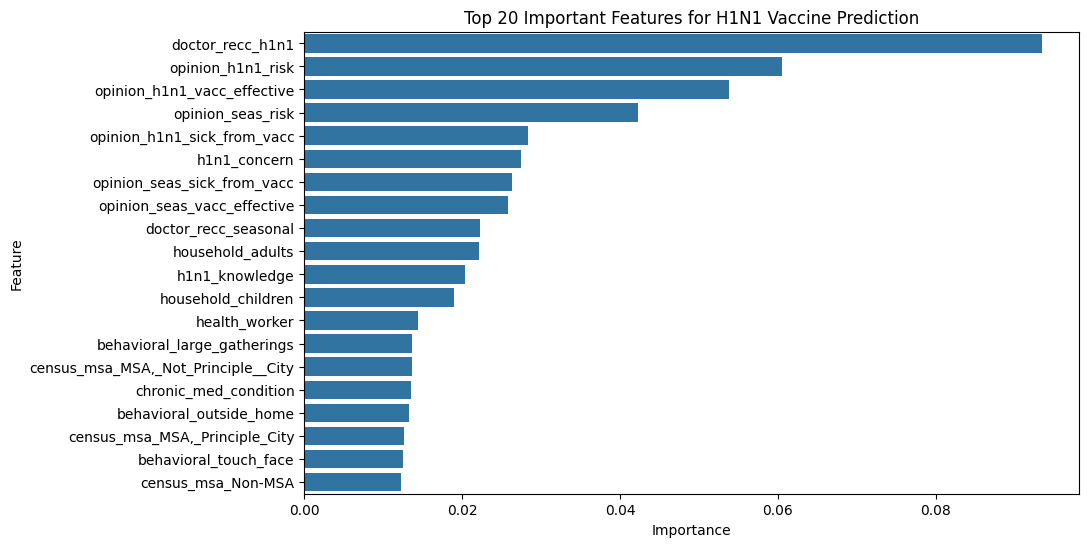

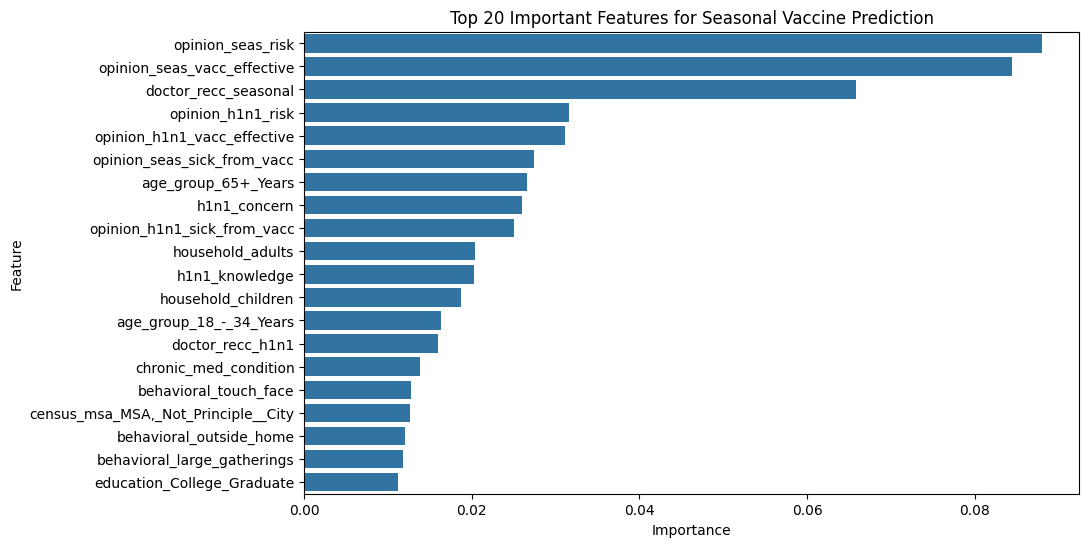

In [ ]:
# ... (your existing code) ...

# ✅ Get feature importances from the trained model
h1n1_importances = rf_h1n1.feature_importances_
seasonal_importances = rf_seasonal.feature_importances_

# ✅ Create a DataFrame for feature importances
h1n1_importance_df = pd.DataFrame({'feature': X.columns, 'importance': h1n1_importances})
seasonal_importance_df = pd.DataFrame({'feature': X.columns, 'importance': seasonal_importances})

# ✅ Sort by importance
h1n1_importance_df = h1n1_importance_df.sort_values('importance', ascending=False)
seasonal_importance_df = seasonal_importance_df.sort_values('importance', ascending=False)

# ✅ Plot feature importances for H1N1 vaccine
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=h1n1_importance_df.head(20))  # Show top 20 features
plt.title('Top 20 Important Features for H1N1 Vaccine Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# ✅ Plot feature importances for Seasonal vaccine
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=seasonal_importance_df.head(20))  # Show top 20 features
plt.title('Top 20 Important Features for Seasonal Vaccine Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

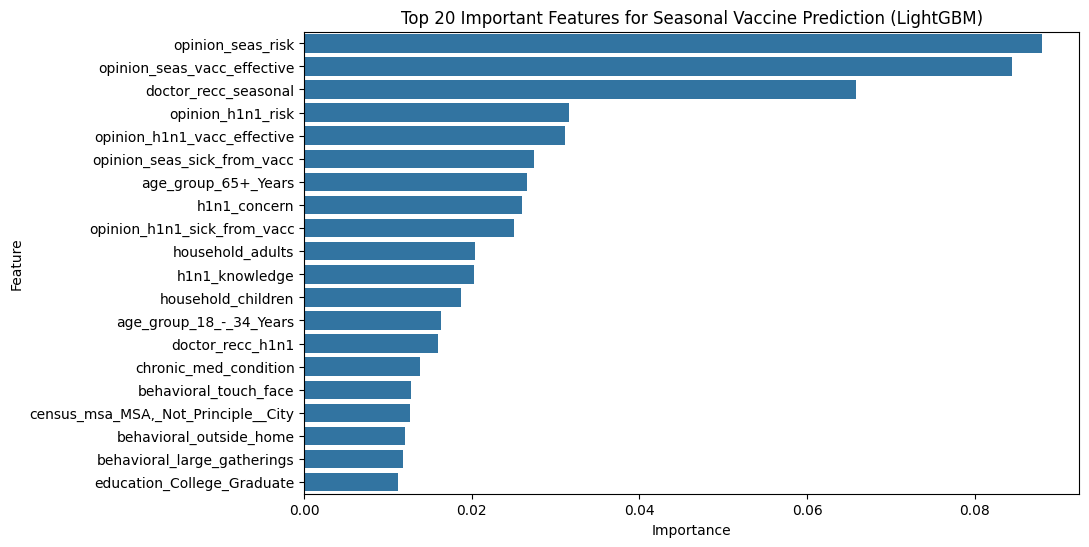

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have already trained your LightGBM model (h1n1_lgbm) and have your feature data (X_train)

# Get feature importances
importance = rf_seasonal.feature_importances_

# Create a DataFrame for feature importances
feature_imp_df = pd.DataFrame({'feature': X.columns, 'importance': importance})

# Sort by importance
feature_imp_df = feature_imp_df.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_imp_df.head(20))  # Show top 20 features
plt.title('Top 20 Important Features for Seasonal Vaccine Prediction (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

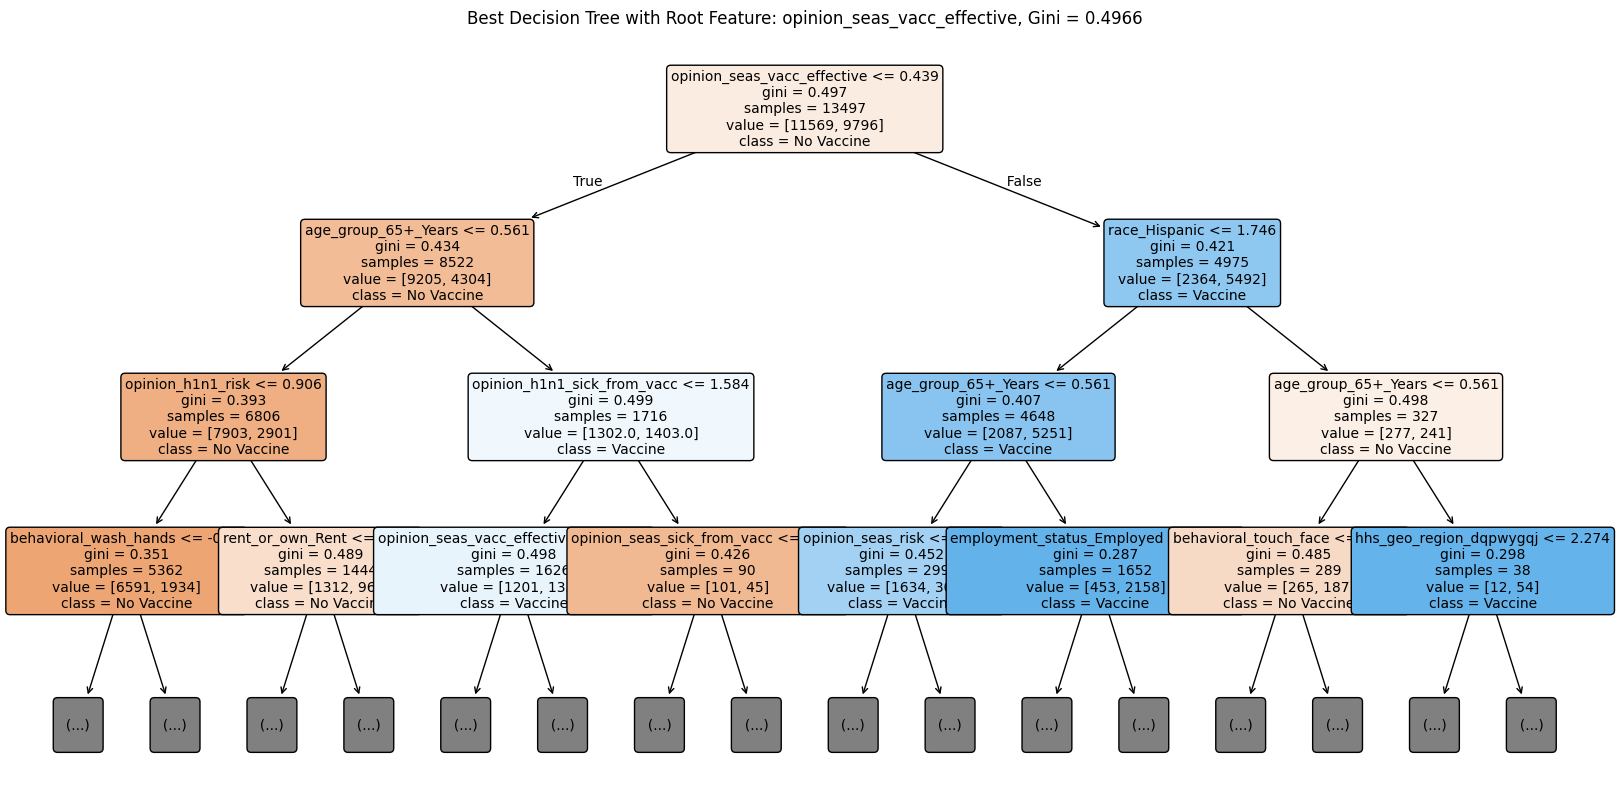

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

root_node_features = []
gini_values = []
for tree in rf_seasonal.estimators_:
    root_node_features.append(X.columns[tree.tree_.feature[0]])
    gini_values.append(tree.tree_.impurity[0])

# --- Create DataFrame for sorting ---
tree_data = pd.DataFrame({'tree_index': range(len(gini_values)),
                         'root_feature': root_node_features,
                         'gini_value': gini_values})

# --- Find the majority vote feature ---
majority_vote_feature = Counter(root_node_features).most_common(1)[0][0]

# --- Filter trees with the majority vote feature and find the one with the least Gini ---
best_tree_index = tree_data[tree_data['root_feature'] == majority_vote_feature]['gini_value'].idxmin()

# --- Get the best tree ---
best_tree = rf_seasonal.estimators_[best_tree_index]

# --- Visualize the best tree ---
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X.columns,
          class_names=['No Vaccine', 'Vaccine'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Adjust max_depth as needed
plt.title(f"Best Decision Tree with Root Feature: {majority_vote_feature}, Gini = {tree_data.loc[best_tree_index, 'gini_value']:.4f}")
plt.show()

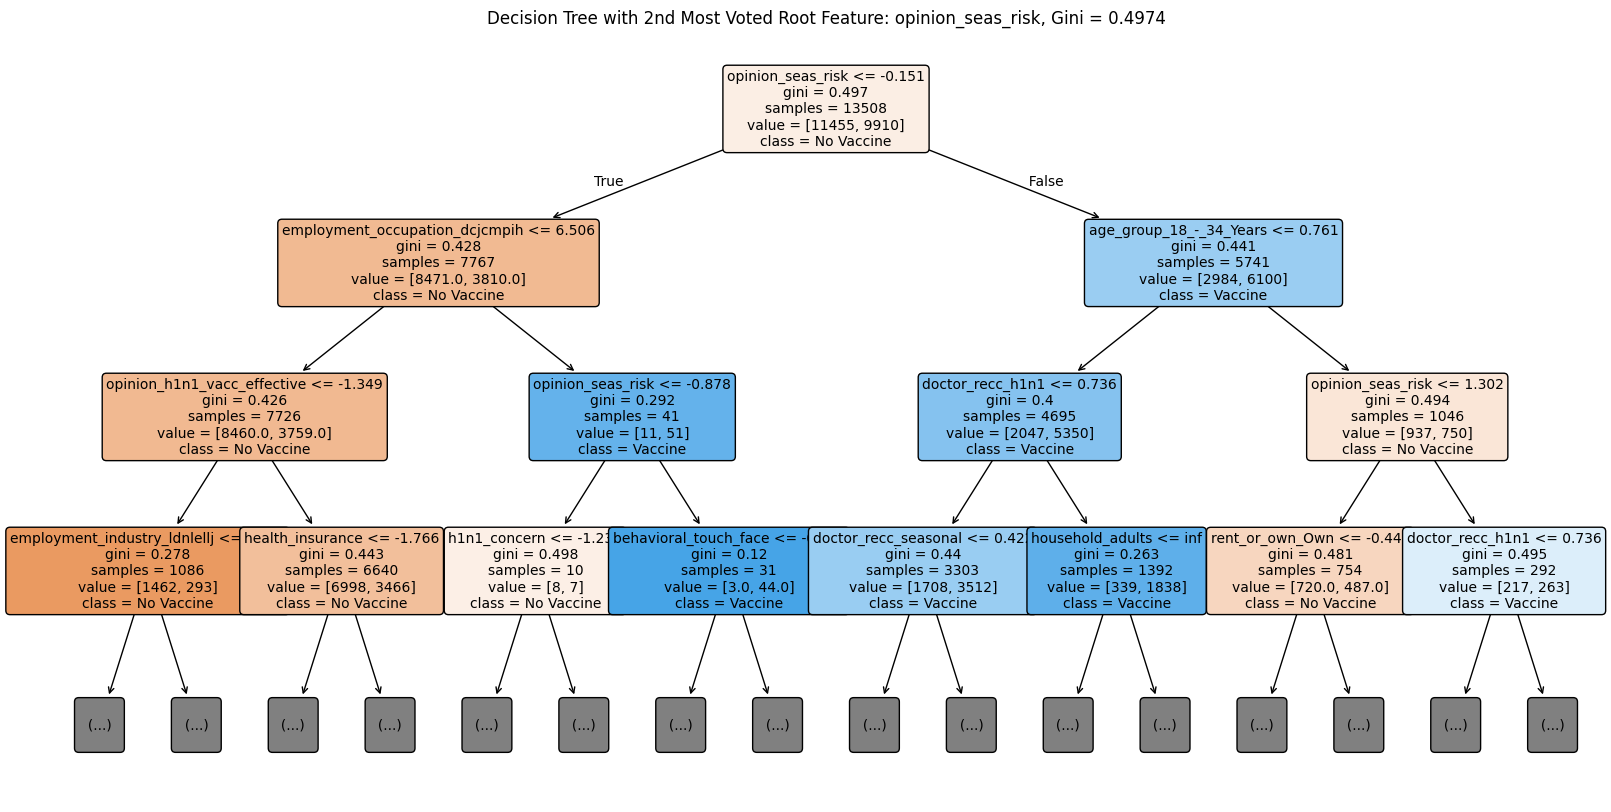

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

# Assuming you have trained rf_h1n1 and have feature data X

# --- Get root node features and Gini values ---
root_node_features = []
gini_values = []
for tree in rf_seasonal.estimators_:
    root_node_features.append(X.columns[tree.tree_.feature[0]])
    gini_values.append(tree.tree_.impurity[0])

# --- Create DataFrame for sorting ---
tree_data = pd.DataFrame({'tree_index': range(len(gini_values)),
                         'root_feature': root_node_features,
                         'gini_value': gini_values})

# --- Find the 2nd most voted feature ---
# Get the two most common features
two_most_common = Counter(root_node_features).most_common(2)

# If there's more than one feature, get the 2nd one
if len(two_most_common) > 1:
    second_most_voted_feature = two_most_common[1][0]
else:
    # Handle the case where there's only one unique root feature
    second_most_voted_feature = two_most_common[0][0]  # Use the most common in this case

# --- Filter trees and find the one with least Gini ---
filtered_trees = tree_data[tree_data['root_feature'] == second_most_voted_feature]
best_tree_index = filtered_trees['gini_value'].idxmin()
best_tree = rf_seasonal.estimators_[best_tree_index]

# --- Visualize the best tree ---
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X.columns,
          class_names=['No Vaccine', 'Vaccine'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Adjust max_depth as needed
plt.title(f"Decision Tree with 2nd Most Voted Root Feature: {second_most_voted_feature}, Gini = {tree_data.loc[best_tree_index, 'gini_value']:.4f}")
plt.show()

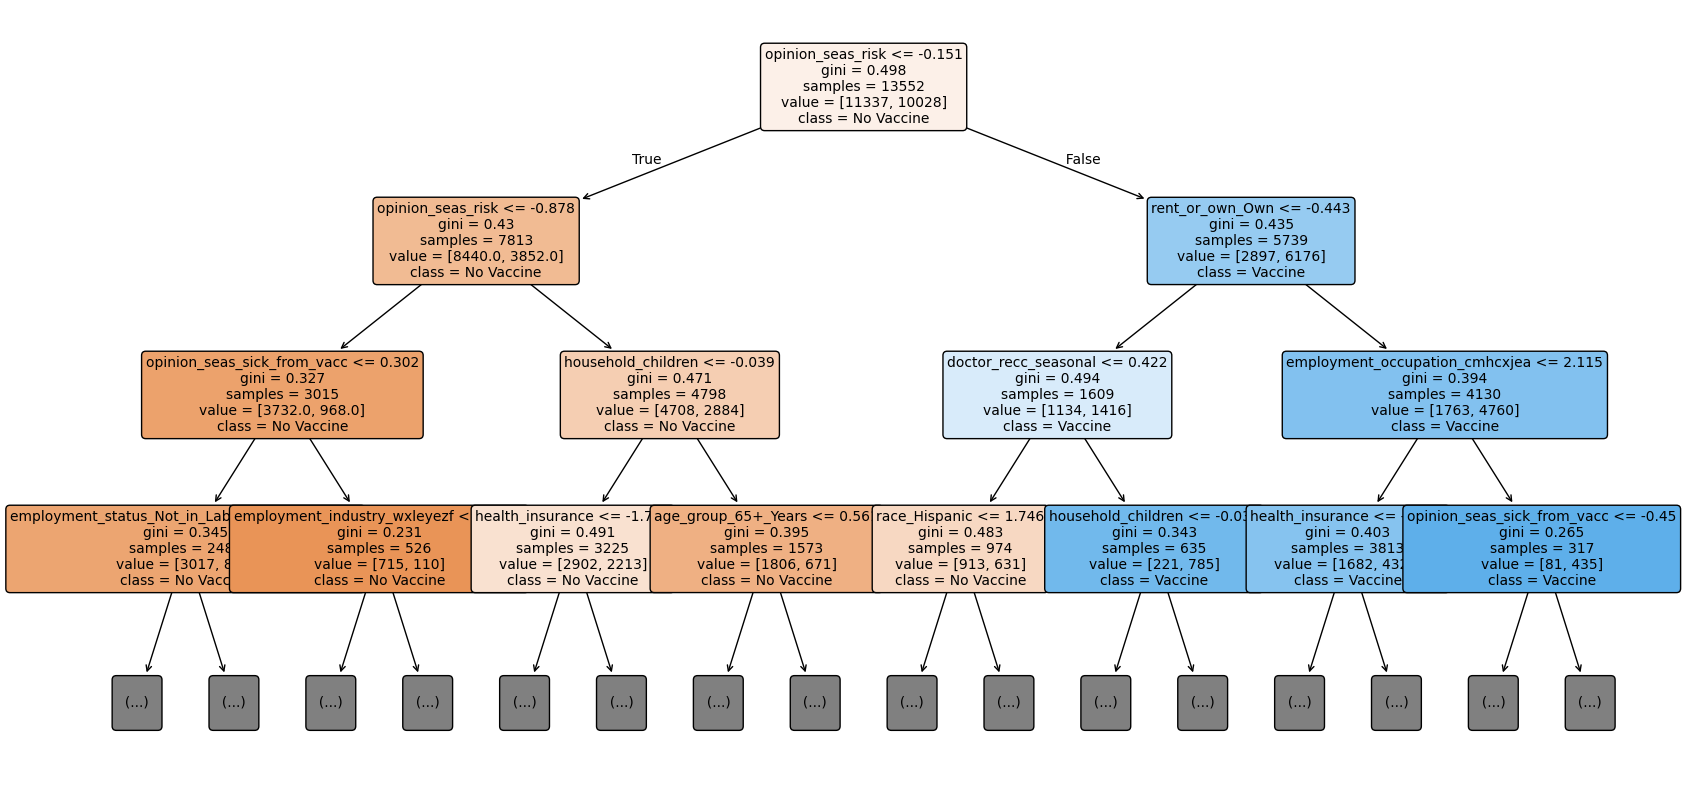

In [ ]:
from sklearn.tree import plot_tree

# Choose the model and tree index (e.g., the first tree)
tree_to_plot1 = rf_seasonal.estimators_[0]  # Select the first tree from rf_h1n1

# Plot the tree
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
plot_tree(tree_to_plot1,
          feature_names=X.columns,
          class_names=['No Vaccine', 'Vaccine'],  # Adjust class names if needed
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Adjust fontsize as needed
plt.show()

In [ ]:
def dropRow(df, noColumns):
  null_count = 0
  row_count = 0
  for row in df.index:
    for col in noColumns:
      if pd.isnull(df.loc[row, col]):
        null_count += 1

    if(null_count > 15):
      # print(df.loc[row, 'respondent_id'], null_count)
      df.drop(row, inplace=True)
      row_count += 1

    null_count = 0

  print(row_count, "rows dropped")
  return df
trainData_real = dropRow(trainData_copy, trainData_copy.columns)

192 rows dropped


In [ ]:
trainData_real.shape

(26515, 38)

# Data Visualizations

In [ ]:
trainData_real_Male = trainData[trainData['sex']== 'Male']
trainData_real_Female = trainData[trainData['sex']== 'Female']

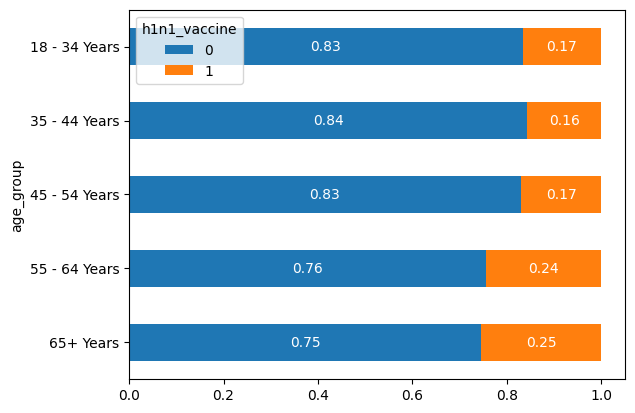

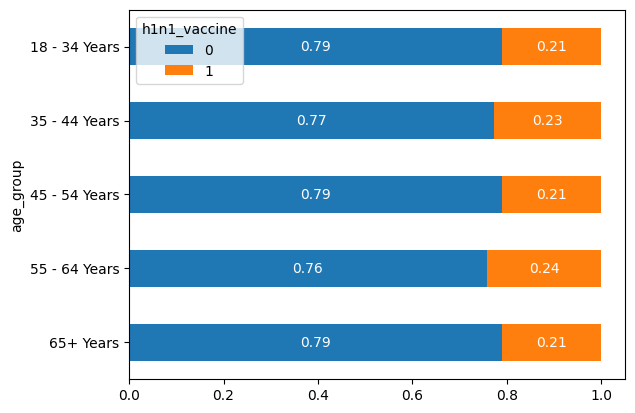

In [ ]:
counts = (trainData_real_Male[['h1n1_vaccine', 'age_group']]
                  .groupby(['h1n1_vaccine', 'age_group'])
                  .size()
                  .unstack('h1n1_vaccine')
             )
group_counts = counts.sum(axis='columns')
props = counts.div(group_counts, axis='index')

ax = props.plot(kind="barh", stacked=True, ax=None)
ax.invert_yaxis()

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width/2,
            y + height/2,
            '{:.2f}'.format(width),
            ha='center',
            va='center',
            color='white') # Adjust color for visibility


counts = (trainData_real_Female[['h1n1_vaccine', 'age_group']]
                  .groupby(['h1n1_vaccine', 'age_group'])
                  .size()
                  .unstack('h1n1_vaccine')
             )
group_counts = counts.sum(axis='columns')
props = counts.div(group_counts, axis='index')

ax = props.plot(kind="barh", stacked=True, ax=None)
ax.invert_yaxis()

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width/2,
            y + height/2,
            '{:.2f}'.format(width),
            ha='center',
            va='center',
            color='white') # Adjust color for visibility

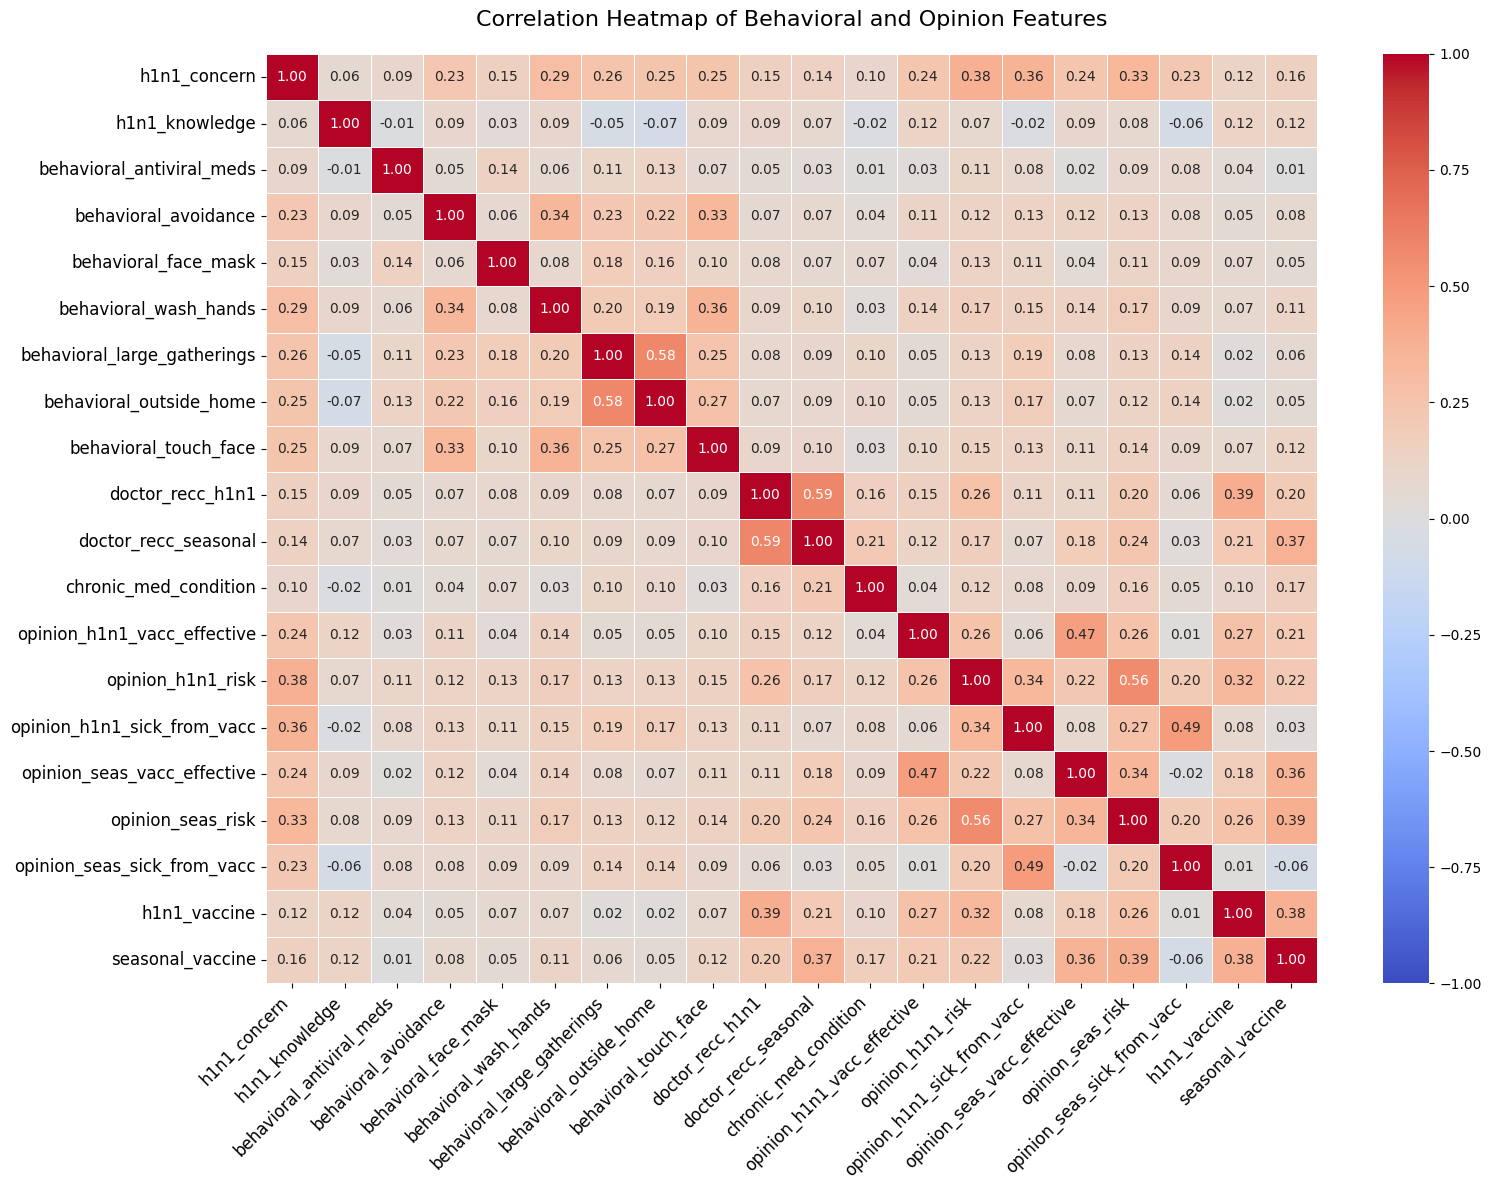

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the dataset is loaded into a pandas DataFrame called `df`
# Example: df = pd.read_csv('vaccination_data.csv')

# Select relevant columns for the heatmap
columns_for_heatmap = [
    'h1n1_concern', 'h1n1_knowledge',
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
    'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'h1n1_vaccine', 'seasonal_vaccine'
]

# Subset the DataFrame with selected columns
df_subset = trainData_real[columns_for_heatmap]

# Calculate the correlation matrix
corr_matrix = df_subset.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10}
)

# Customize the plot
plt.title('Correlation Heatmap of Behavioral and Opinion Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

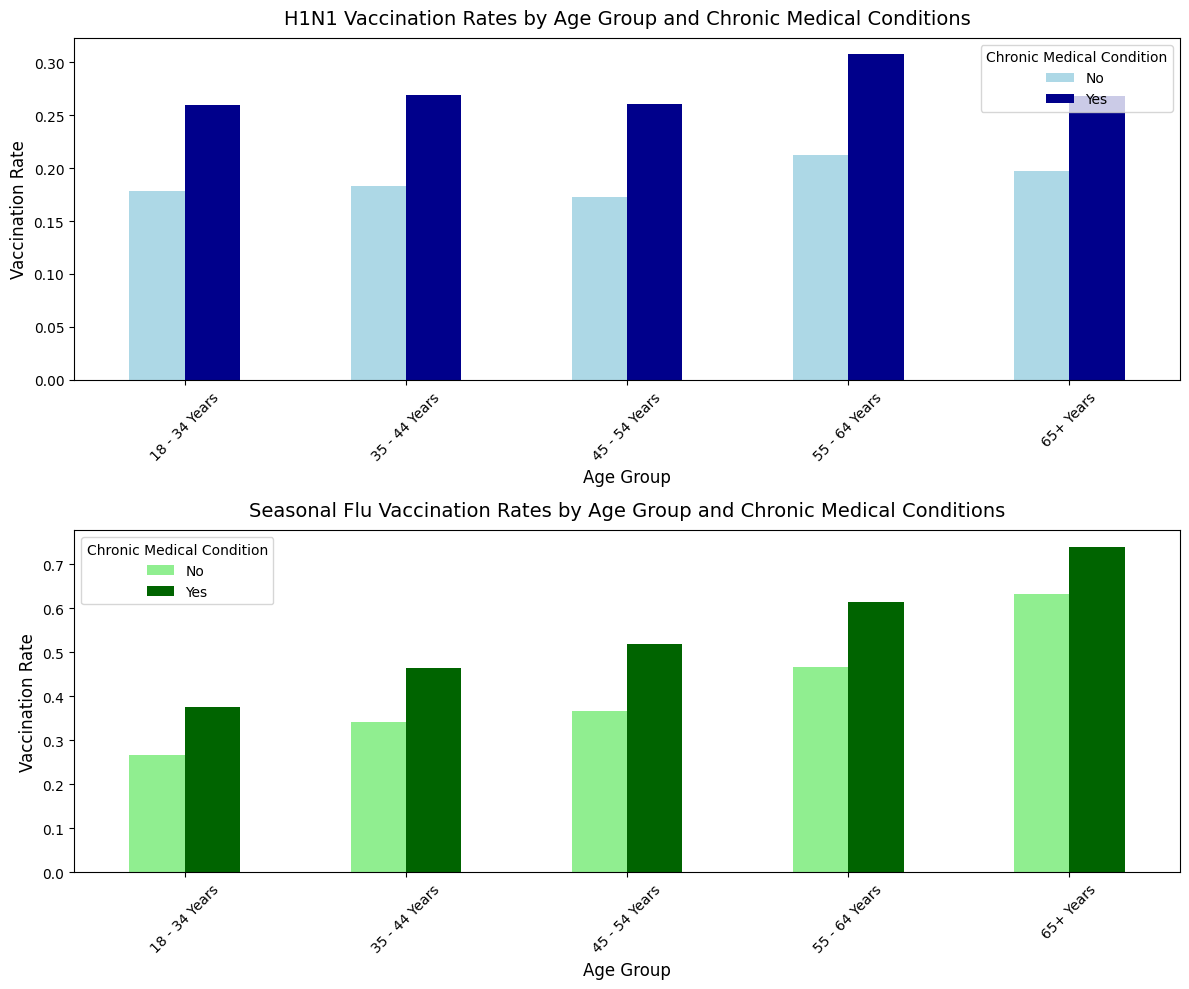

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group the data by age_group and chronic_med_condition, and calculate vaccination rates
vaccination_rates = trainData_real.groupby(['age_group', 'chronic_med_condition'])[['h1n1_vaccine', 'seasonal_vaccine']].mean().reset_index()

# Pivot the data for easier plotting
h1n1_rates = vaccination_rates.pivot(index='age_group', columns='chronic_med_condition', values='h1n1_vaccine')
seasonal_rates = vaccination_rates.pivot(index='age_group', columns='chronic_med_condition', values='seasonal_vaccine')

# Plot the stacked bar chart
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot for H1N1 vaccine
h1n1_rates.plot(kind='bar', stacked=False, ax=ax[0], color=['lightblue', 'darkblue'])
ax[0].set_title('H1N1 Vaccination Rates by Age Group and Chronic Medical Conditions', fontsize=14, pad=10)
ax[0].set_ylabel('Vaccination Rate', fontsize=12)
ax[0].set_xlabel('Age Group', fontsize=12)
ax[0].legend(title='Chronic Medical Condition', labels=['No', 'Yes'], fontsize=10)
ax[0].tick_params(axis='x', rotation=45)

# Plot for Seasonal flu vaccine
seasonal_rates.plot(kind='bar', stacked=False, ax=ax[1], color=['lightgreen', 'darkgreen'])
ax[1].set_title('Seasonal Flu Vaccination Rates by Age Group and Chronic Medical Conditions', fontsize=14, pad=10)
ax[1].set_ylabel('Vaccination Rate', fontsize=12)
ax[1].set_xlabel('Age Group', fontsize=12)
ax[1].legend(title='Chronic Medical Condition', labels=['No', 'Yes'], fontsize=10)
ax[1].tick_params(axis='x', rotation=45)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

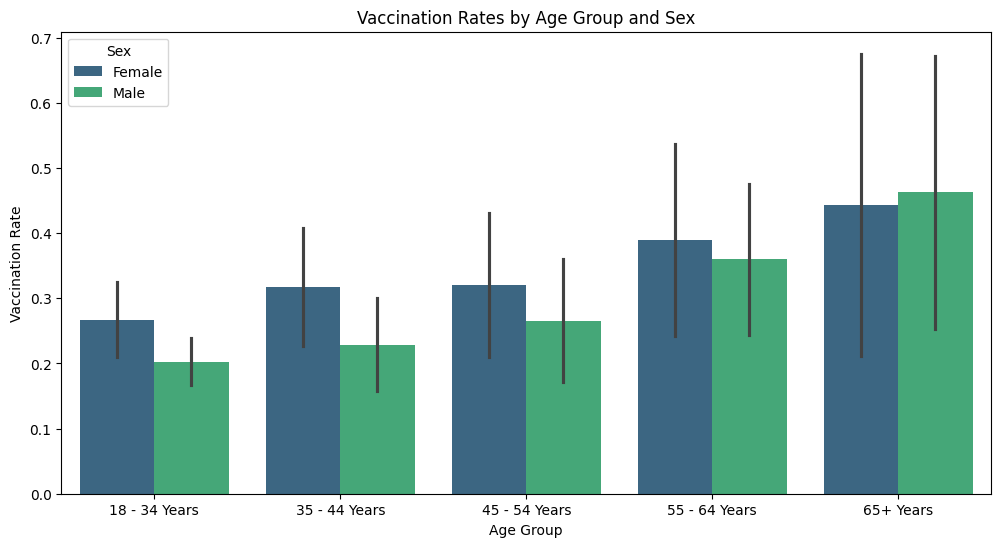

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by age_group and sex, then calculate mean vaccination rates
grouped_data = trainData_real.groupby(['age_group', 'sex'])[['h1n1_vaccine', 'seasonal_vaccine']].mean().reset_index()

# Melt the DataFrame for easier plotting
melted_data = pd.melt(grouped_data, id_vars=['age_group', 'sex'],
                      value_vars=['h1n1_vaccine', 'seasonal_vaccine'],
                      var_name='vaccine_type', value_name='vaccination_rate')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='age_group', y='vaccination_rate', hue='sex', data=melted_data, palette='viridis')
plt.title('Vaccination Rates by Age Group and Sex')
plt.xlabel('Age Group')
plt.ylabel('Vaccination Rate')
plt.legend(title='Sex')
plt.show()

<ipython-input-20-320e98eb38e9>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='doctor_recc_h1n1', y='h1n1_vaccine', data=vaccination_rates_by_recc, palette='viridis')


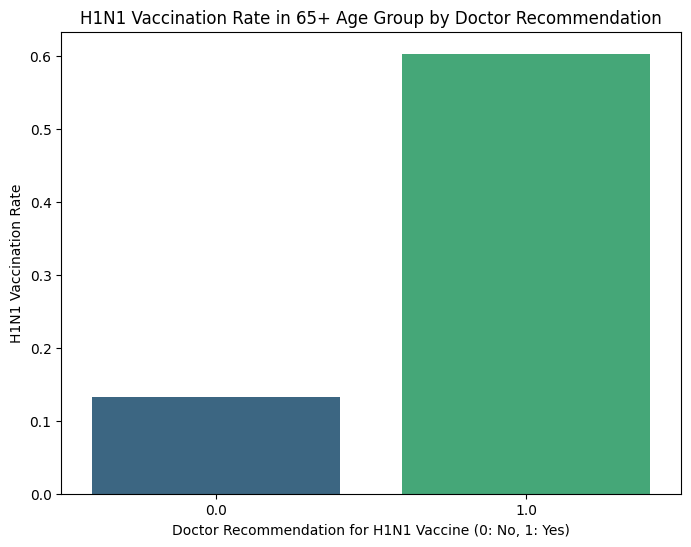

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the 65+ age group
data_65plus = trainData_real[trainData_real['age_group'] == '65+ Years']

# Group by doctor recommendation and calculate vaccination rates
vaccination_rates_by_recc = data_65plus.groupby('doctor_recc_h1n1')['h1n1_vaccine'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='doctor_recc_h1n1', y='h1n1_vaccine', data=vaccination_rates_by_recc, palette='viridis')
plt.title('H1N1 Vaccination Rate in 65+ Age Group by Doctor Recommendation')
plt.xlabel('Doctor Recommendation for H1N1 Vaccine (0: No, 1: Yes)')
plt.ylabel('H1N1 Vaccination Rate')
plt.show()

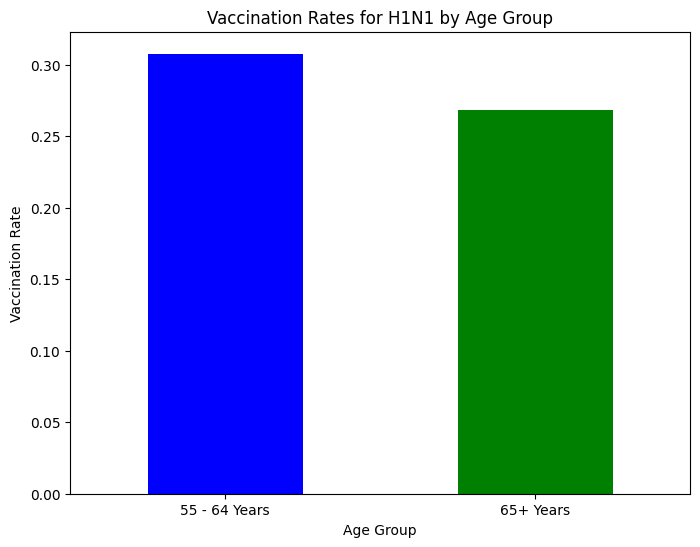

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = trainData_real

# Filter data for 55-64 and 65+ age groups with chronic medical conditions
filtered_data = df[(df['age_group'].isin(['55 - 64 Years', '65+ Years'])) & (df['chronic_med_condition'] == 1)]

# Group by age group and calculate mean vaccination rates
vaccination_rates = filtered_data.groupby('age_group')['h1n1_vaccine'].mean()

# Plotting
plt.figure(figsize=(8, 6))
vaccination_rates.plot(kind='bar', color=['blue', 'green'])
plt.title('Vaccination Rates for H1N1 by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Vaccination Rate')
plt.xticks(rotation=0)
plt.show()


In [ ]:
import statsmodels.api as sm
import numpy as np

# Select relevant features and the target variable
X = filtered_data[['doctor_recc_h1n1', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'health_worker']]
y = filtered_data['h1n1_vaccine']

# Handle inf and NaN values in X
# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)
# Impute or drop NaN values
# Option 1: Drop rows with NaN values
X = X.dropna()
y = y[X.index] # Ensure y aligns with dropped rows in X
# Option 2: Impute NaN values with the mean of the column
# X = X.fillna(X.mean())

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X).fit()

# Print the summary of the model
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.455933
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           h1n1_vaccine   No. Observations:                 2530
Model:                          Logit   Df Residuals:                     2524
Method:                           MLE   Df Model:                            5
Date:                Sat, 08 Feb 2025   Pseudo R-squ.:                  0.3214
Time:                        05:08:44   Log-Likelihood:                -1153.5
converged:                       True   LL-Null:                       -1699.8
Covariance Type:            nonrobust   LLR p-value:                5.196e-234
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -5.8878      0.385    -15.301      0.000   